# Mounting everything and the folder path.

In [1]:
# 1. Mount Drive
from google.colab import drive
drive.mount('/content/drive')

# 2. Check what GPU you got
!nvidia-smi

# 3. Install deps (same as your training script needs)
!pip install --quiet torch torchio SimpleITK

# 4. Point to your two dataset roots
ORIGINAL_PATH = '/content/drive/MyDrive/<your original folder>'
SYNTHETIC_PATH = '/content/drive/MyDrive/<your synthetic folder>'

Mounted at /content/drive
Sat Jul 11 10:11:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+---------------------

# Checking what is inside Synthetic data folder.

In [2]:
!ls /content/drive/MyDrive/<preprocessed folder>/case1
!ls /content/drive/MyDrive/<preprocessed folder>/synthetic

/bin/bash: line 1: preprocessed: No such file or directory
/bin/bash: line 1: preprocessed: No such file or directory


In [3]:
import os
for item in os.listdir('/content/drive/MyDrive'):
    print(item)

Colab Notebooks
dirlab_preprocessed
ubuntu file sharing
20251204_224656.jpg
20251204_224624.jpg
Passport Important Documents
baseline_unet.pth
Dataset 4DCT


In [4]:
import os
BASE = '/content/drive/MyDrive/dirlab_preprocessed'
print("Top level:", os.listdir(BASE))
print("\ncase1 contents:", os.listdir(os.path.join(BASE, 'case1')))
print("\nsynthetic contents:", os.listdir(os.path.join(BASE, 'synthetic')))

Top level: ['case1', 'case2', 'case3', 'case4', 'case5', 'case6', 'case7', 'case8', 'case9', 'case10', 'synthetic']

case1 contents: ['T00.npy', 'T10.npy', 'T20.npy', 'T30.npy', 'T40.npy', 'T50.npy', 'T60.npy', 'T70.npy', 'T80.npy', 'T90.npy']

synthetic contents: ['case1', 'case2', 'case4', 'case5', 'case6', 'case7', 'case8', 'case10']


In [5]:
print(os.listdir(os.path.join(BASE, 'synthetic', 'case1')))

['T10_synth.npy', 'T20_synth.npy', 'T30_synth.npy', 'T40_synth.npy', 'T60_synth.npy', 'T70_synth.npy', 'T80_synth.npy', 'T90_synth.npy']


# Diffusion Training

In [9]:
import os
import numpy as np
import torch
from torch.utils.data import Dataset

BASE = '/content/drive/MyDrive/dirlab_preprocessed'

TRAIN_CASES = [1, 2, 4, 5, 6, 7, 8, 10]   # case4 back in, real-only
VAL_CASES   = [3, 9]

INTERMEDIATE_PHASES = ["T10", "T20", "T30", "T40", "T60", "T70", "T80", "T90"]

# Cases where synthetic data should NOT be used, even if the folder exists
# (case4: ANTs registration failed irrecoverably — synthetic folder may contain
# partial/corrupted leftovers from that failed run)
SYNTHETIC_BLOCKLIST = {4}

class CombinedPhaseDataset(Dataset):
    def __init__(self, base_dir, case_ids, use_synthetic=True):
        self.base_dir = base_dir
        self.samples = []  # each entry: (case_id, phase, source)

        for cid in case_ids:
            case_name = f"case{cid}"
            real_dir = os.path.join(base_dir, case_name)
            synth_dir = os.path.join(base_dir, "synthetic", case_name)

            if not os.path.exists(real_dir):
                print(f"⚠️ Missing real folder for {case_name}, skipping")
                continue

            case_allows_synth = use_synthetic and (cid not in SYNTHETIC_BLOCKLIST)

            for phase in INTERMEDIATE_PHASES:
                real_path = os.path.join(real_dir, f"{phase}.npy")
                if os.path.exists(real_path):
                    self.samples.append((cid, phase, "real"))

                if case_allows_synth and os.path.exists(synth_dir):
                    synth_path = os.path.join(synth_dir, f"{phase}_synth.npy")
                    if os.path.exists(synth_path):
                        self.samples.append((cid, phase, "synthetic"))

        n_real = sum(1 for s in self.samples if s[2] == 'real')
        n_synth = sum(1 for s in self.samples if s[2] == 'synthetic')
        print(f"Dataset built: {len(self.samples)} samples across {len(case_ids)} cases "
              f"({n_real} real, {n_synth} synthetic)")

    def __len__(self):
        return len(self.samples)

    def _load(self, filename_dir, filename):
        path = os.path.join(filename_dir, filename)
        arr = np.load(path).astype(np.float32)
        return torch.from_numpy(arr).unsqueeze(0)  # add channel dim -> [1, D, H, W]

    def __getitem__(self, idx):
        cid, phase, source = self.samples[idx]
        case_name = f"case{cid}"
        real_dir = os.path.join(self.base_dir, case_name)

        # Anchors always come from the real folder
        t00 = self._load(real_dir, "T00.npy")
        t50 = self._load(real_dir, "T50.npy")

        # Target depends on source
        if source == "real":
            target = self._load(real_dir, f"{phase}.npy")
        else:
            synth_dir = os.path.join(self.base_dir, "synthetic", case_name)
            target = self._load(synth_dir, f"{phase}_synth.npy")

        phase_value = int(phase[1:]) / 100.0  # "T30" -> 0.3

        return {
            "target": target,
            "t00": t00,
            "t50": t50,
            "phase": torch.tensor(phase_value, dtype=torch.float32),
            "case_id": cid,
            "source": source,
        }


# Quick sanity check
train_dataset = CombinedPhaseDataset(BASE, TRAIN_CASES, use_synthetic=True)
val_dataset   = CombinedPhaseDataset(BASE, VAL_CASES, use_synthetic=False)

sample = train_dataset[0]
print("Target shape:", sample["target"].shape)
print("Phase:", sample["phase"].item(), "| Source:", sample["source"], "| Case:", sample["case_id"])

Dataset built: 120 samples across 8 cases (64 real, 56 synthetic)
Dataset built: 16 samples across 2 cases (16 real, 0 synthetic)
Target shape: torch.Size([1, 94, 256, 256])
Phase: 0.10000000149011612 | Source: real | Case: 1


In [7]:
case4_dir = os.path.join(BASE, 'case4')
print(os.path.exists(case4_dir))
print(os.listdir(case4_dir) if os.path.exists(case4_dir) else "missing")

True
['T00.npy', 'T10.npy', 'T20.npy', 'T30.npy', 'T40.npy', 'T50.npy', 'T60.npy', 'T70.npy', 'T80.npy', 'T90.npy']


# Another Run (5 epoch first then 50 epoch)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
BASE = '/content/drive/MyDrive/dirlab_preprocessed'
print(os.listdir(BASE))  # confirm it's the same structure as before

Mounted at /content/drive
['case1', 'case2', 'case3', 'case4', 'case5', 'case6', 'case7', 'case8', 'case9', 'case10', 'synthetic']


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np

BASE = '/content/drive/MyDrive/dirlab_preprocessed'
print(os.listdir(BASE))

sample = np.load(os.path.join(BASE, 'case1', 'T30.npy'))
print("dtype:", sample.dtype)
print("min:", sample.min(), "max:", sample.max())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['case1', 'case2', 'case3', 'case4', 'case5', 'case6', 'case7', 'case8', 'case9', 'case10', 'synthetic']
dtype: float32
min: -1.0 max: 1.0


In [3]:
path = '/content/diffusion_training.py'

with open(path, 'r') as f:
    content = f.read()

old_norm = '''        def norm(x):
            return np.clip(x, -1000, 1000) / 1000.0'''

new_norm = '''        def norm(x):
            return x  # data already normalized to [-1, 1] during preprocessing'''

if old_norm in content:
    content = content.replace(old_norm, new_norm)
    with open(path, 'w') as f:
        f.write(content)
    print("✓ Patched norm() to pass-through — no double normalization.")
else:
    print("⚠️ Exact block not found — check indentation, may need manual fix.")

✓ Patched norm() to pass-through — no double normalization.


In [4]:
import sys
sys.path.append('/content')

from unet3d_film import UNet3DFiLM
from diffusion_training import PhasePatchDataset, NoiseScheduler, train, INTERMEDIATE_PHASES
from torch.utils.data import DataLoader
import torch

TRAIN_CASES = [1, 2, 4, 5, 6, 7, 8, 10]
VAL_CASES = [3, 9]
SYNTHETIC_BLOCKLIST = {4}  # case4: ANTs registration failed, don't trust its synthetic folder

SYNTHETIC_ROOT = os.path.join(BASE, 'synthetic')
synthetic_case_ids = [c for c in TRAIN_CASES if c not in SYNTHETIC_BLOCKLIST]

train_dataset = PhasePatchDataset(
    data_root=BASE,
    case_ids=TRAIN_CASES,
    patch_size=32,                      # small, for a quick first result
    synthetic_root=SYNTHETIC_ROOT,
    synthetic_case_ids=synthetic_case_ids,
)

val_dataset = PhasePatchDataset(
    data_root=BASE,
    case_ids=VAL_CASES,
    patch_size=32,
    synthetic_root=None,                # never synthetic for validation
)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples:   {len(val_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

model = UNet3DFiLM(in_channels=3, out_channels=1, base_ch=16)
scheduler = NoiseScheduler(num_timesteps=1000, device=device)

CHECKPOINT_DIR = os.path.join(BASE, "..", "checkpoints_first_run")  # saved to Drive, survives disconnects

history = train(
    model, train_loader, scheduler,
    device=device,
    epochs=5,               # small, just to get a first working result
    lr=1e-4,
    checkpoint_dir=CHECKPOINT_DIR,
)

Train samples: 120
Val samples:   16
Device: cuda
Epoch 1/5 -- avg MSE loss: 0.68234
Epoch 2/5 -- avg MSE loss: 0.22436
Epoch 3/5 -- avg MSE loss: 0.11145
Epoch 4/5 -- avg MSE loss: 0.10786
Epoch 5/5 -- avg MSE loss: 0.07193


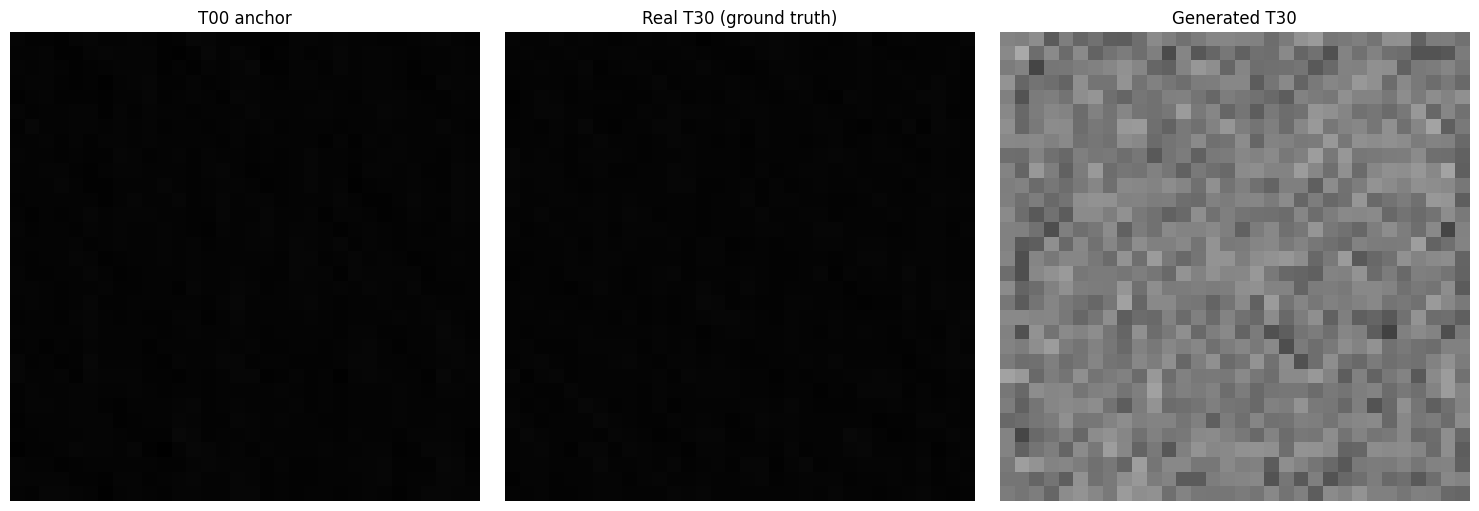

Generated value range: -0.680396 0.6721833


In [5]:
import sys
sys.path.append('/content')

from ddim_sampling import DDIMSampler
from unet3d_film import UNet3DFiLM
from diffusion_training import NoiseScheduler
import numpy as np
import torch
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load the trained checkpoint
model = UNet3DFiLM(in_channels=3, out_channels=1, base_ch=16)
model.load_state_dict(torch.load(os.path.join(BASE, "..", "checkpoints_first_run", "epoch_5.pt"), map_location=device))
model.to(device)

scheduler = NoiseScheduler(num_timesteps=1000, device=device)
sampler = DDIMSampler(model, scheduler, num_steps=50, device=device)

# Load case3's real anchors (already normalized to [-1,1], no need to re-norm)
case_dir = os.path.join(BASE, "case3")
t00 = np.load(os.path.join(case_dir, "T00.npy")).astype(np.float32)
t50 = np.load(os.path.join(case_dir, "T50.npy")).astype(np.float32)
t30_real = np.load(os.path.join(case_dir, "T30.npy")).astype(np.float32)

# Crop a patch matching training patch size (32^3) from the same location for a fair look
patch = 32
z, y, x = 0, 0, 0  # start corner; adjust if you want a different region
def crop(vol): return vol[z:z+patch, y:y+patch, x:x+patch]

t00_patch = torch.from_numpy(crop(t00)).unsqueeze(0).unsqueeze(0).to(device)
t50_patch = torch.from_numpy(crop(t50)).unsqueeze(0).unsqueeze(0).to(device)
t30_real_patch = crop(t30_real)

generated = sampler.generate(t00_patch, t50_patch, phase=0.3, volume_shape=(patch, patch, patch))
generated_np = generated.squeeze().cpu().numpy()

# Visualize middle slice: real T30 vs generated T30
mid = patch // 2
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(crop(t00)[mid], cmap='gray', vmin=-1, vmax=1); axes[0].set_title("T00 anchor"); axes[0].axis('off')
axes[1].imshow(t30_real_patch[mid], cmap='gray', vmin=-1, vmax=1); axes[1].set_title("Real T30 (ground truth)"); axes[1].axis('off')
axes[2].imshow(generated_np[mid], cmap='gray', vmin=-1, vmax=1); axes[2].set_title("Generated T30"); axes[2].axis('off')
plt.tight_layout()
plt.show()

print("Generated value range:", generated_np.min(), generated_np.max())

T30 patch value range: -0.99285716 0.6042857 | mean: 0.4472078


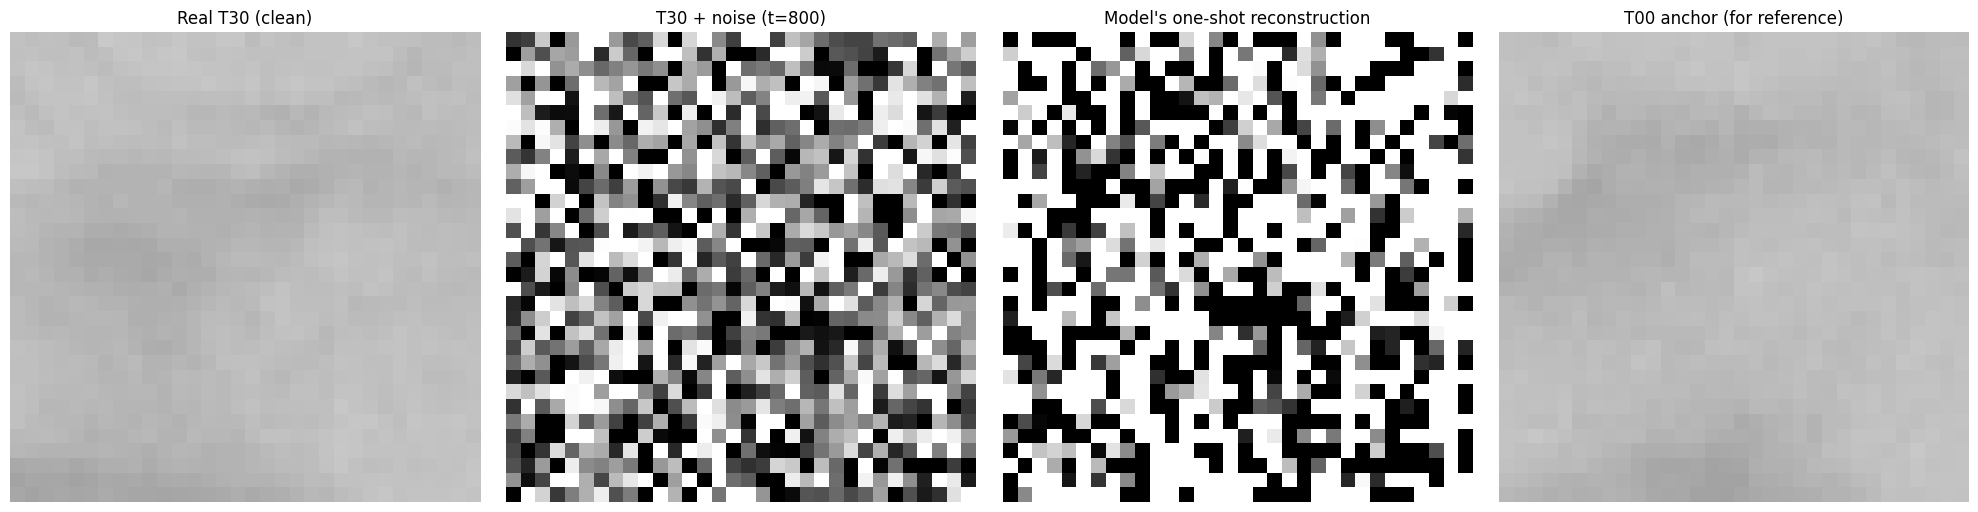

Reconstruction MSE vs real T30: 0.91926


In [7]:
import sys
sys.path.append('/content')

from unet3d_film import UNet3DFiLM
from diffusion_training import NoiseScheduler
import numpy as np
import torch
import matplotlib.pyplot as plt
import os

device = "cuda" if torch.cuda.is_available() else "cpu"

model = UNet3DFiLM(in_channels=3, out_channels=1, base_ch=16)
model.load_state_dict(torch.load(os.path.join(BASE, "..", "checkpoints_first_run", "epoch_5.pt"), map_location=device))
model.to(device).eval()

scheduler = NoiseScheduler(num_timesteps=1000, device=device)

# Load case3 (validation, unseen) full volumes
case_dir = os.path.join(BASE, "case3")
t00 = np.load(os.path.join(case_dir, "T00.npy")).astype(np.float32)
t50 = np.load(os.path.join(case_dir, "T50.npy")).astype(np.float32)
t30_real = np.load(os.path.join(case_dir, "T30.npy")).astype(np.float32)

# Crop from the CENTER this time, not the corner -- actual lung tissue lives here
patch = 32
D, H, W = t30_real.shape
z0 = D // 2 - patch // 2
y0 = H // 2 - patch // 2
x0 = W // 2 - patch // 2

def crop(vol):
    return vol[z0:z0+patch, y0:y0+patch, x0:x0+patch]

t00_patch = crop(t00)
t50_patch = crop(t50)
t30_patch = crop(t30_real)

# Confirm this patch actually has tissue, not empty space
print("T30 patch value range:", t30_patch.min(), t30_patch.max(), "| mean:", t30_patch.mean())

t00_t = torch.from_numpy(t00_patch).unsqueeze(0).unsqueeze(0).to(device)
t50_t = torch.from_numpy(t50_patch).unsqueeze(0).unsqueeze(0).to(device)
t30_t = torch.from_numpy(t30_patch).unsqueeze(0).unsqueeze(0).to(device)

# Add a SMALL, known amount of noise (t=100 out of 1000 -- mild, not full noise)
t_level = 800
t_batch = torch.tensor([t_level], device=device)
with torch.no_grad():
    noisy_t30, true_noise = scheduler.add_noise(t30_t, t_batch)

    # Ask the model to predict that noise in a single shot
    model_input = torch.cat([noisy_t30, t00_t, t50_t], dim=1)
    phase_t = torch.tensor([0.3], device=device, dtype=torch.float32)
    predicted_noise = model(model_input, phase_t, t_batch.float())

    # Reconstruct clean image from the prediction
    alpha_bar_t = scheduler.alpha_bars[t_level]
    x0_pred = (noisy_t30 - torch.sqrt(1 - alpha_bar_t) * predicted_noise) / torch.sqrt(alpha_bar_t)
    x0_pred = torch.clamp(x0_pred, -1, 1)

mid = patch // 2
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(t30_patch[mid], cmap='gray', vmin=-1, vmax=1); axes[0].set_title("Real T30 (clean)"); axes[0].axis('off')
axes[1].imshow(noisy_t30.squeeze().cpu().numpy()[mid], cmap='gray', vmin=-1, vmax=1); axes[1].set_title(f"T30 + noise (t={t_level})"); axes[1].axis('off')
axes[2].imshow(x0_pred.squeeze().cpu().numpy()[mid], cmap='gray', vmin=-1, vmax=1); axes[2].set_title("Model's one-shot reconstruction"); axes[2].axis('off')
axes[3].imshow(t00_patch[mid], cmap='gray', vmin=-1, vmax=1); axes[3].set_title("T00 anchor (for reference)"); axes[3].axis('off')
plt.tight_layout()
plt.show()

# Quantify how close the reconstruction is to the real thing
mse = np.mean((x0_pred.squeeze().cpu().numpy() - t30_patch) ** 2)
print(f"Reconstruction MSE vs real T30: {mse:.5f}")

In [8]:
import sys
sys.path.append('/content')

from unet3d_film import UNet3DFiLM
from diffusion_training import PhasePatchDataset, NoiseScheduler, train
from torch.utils.data import DataLoader
import torch
import os

TRAIN_CASES = [1, 2, 4, 5, 6, 7, 8, 10]
SYNTHETIC_BLOCKLIST = {4}
SYNTHETIC_ROOT = os.path.join(BASE, 'synthetic')
synthetic_case_ids = [c for c in TRAIN_CASES if c not in SYNTHETIC_BLOCKLIST]

train_dataset = PhasePatchDataset(
    data_root=BASE,
    case_ids=TRAIN_CASES,
    patch_size=32,
    synthetic_root=SYNTHETIC_ROOT,
    synthetic_case_ids=synthetic_case_ids,
)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = UNet3DFiLM(in_channels=3, out_channels=1, base_ch=16)
scheduler = NoiseScheduler(num_timesteps=1000, device=device)

CHECKPOINT_DIR = os.path.join(BASE, "..", "checkpoints_50ep")  # saved to Drive -- survives disconnects

print(f"Training samples: {len(train_dataset)}")
print(f"Device: {device}")

history = train(
    model, train_loader, scheduler,
    device=device,
    epochs=50,
    lr=1e-4,
    checkpoint_dir=CHECKPOINT_DIR,
)

Training samples: 120
Device: cuda
Epoch 1/50 -- avg MSE loss: 0.66381
Epoch 2/50 -- avg MSE loss: 0.18944
Epoch 3/50 -- avg MSE loss: 0.14087
Epoch 4/50 -- avg MSE loss: 0.08322
Epoch 5/50 -- avg MSE loss: 0.07472
Epoch 6/50 -- avg MSE loss: 0.05144
Epoch 7/50 -- avg MSE loss: 0.06172
Epoch 8/50 -- avg MSE loss: 0.06029
Epoch 9/50 -- avg MSE loss: 0.05357
Epoch 10/50 -- avg MSE loss: 0.04999
Epoch 11/50 -- avg MSE loss: 0.03627
Epoch 12/50 -- avg MSE loss: 0.02395
Epoch 13/50 -- avg MSE loss: 0.03293
Epoch 14/50 -- avg MSE loss: 0.03524
Epoch 15/50 -- avg MSE loss: 0.03668
Epoch 16/50 -- avg MSE loss: 0.04174
Epoch 17/50 -- avg MSE loss: 0.04091
Epoch 18/50 -- avg MSE loss: 0.05466
Epoch 19/50 -- avg MSE loss: 0.02866
Epoch 20/50 -- avg MSE loss: 0.04424
Epoch 21/50 -- avg MSE loss: 0.03184
Epoch 22/50 -- avg MSE loss: 0.02575
Epoch 23/50 -- avg MSE loss: 0.02262
Epoch 24/50 -- avg MSE loss: 0.02946
Epoch 25/50 -- avg MSE loss: 0.02645
Epoch 26/50 -- avg MSE loss: 0.01259
Epoch 27/50 

In [9]:
model.load_state_dict(torch.load(os.path.join(CHECKPOINT_DIR, "epoch_50.pt"), map_location=device))
model.eval()

for t_level in [100, 800]:
    t_batch = torch.tensor([t_level], device=device)
    with torch.no_grad():
        noisy_t30, true_noise = scheduler.add_noise(t30_t, t_batch)
        model_input = torch.cat([noisy_t30, t00_t, t50_t], dim=1)
        phase_t = torch.tensor([0.3], device=device, dtype=torch.float32)
        predicted_noise = model(model_input, phase_t, t_batch.float())

        alpha_bar_t = scheduler.alpha_bars[t_level]
        x0_pred = (noisy_t30 - torch.sqrt(1 - alpha_bar_t) * predicted_noise) / torch.sqrt(alpha_bar_t)
        x0_pred = torch.clamp(x0_pred, -1, 1)

    mse = np.mean((x0_pred.squeeze().cpu().numpy() - t30_patch) ** 2)
    print(f"t={t_level}: reconstruction MSE = {mse:.5f}")

t=100: reconstruction MSE = 0.00417
t=800: reconstruction MSE = 0.74095


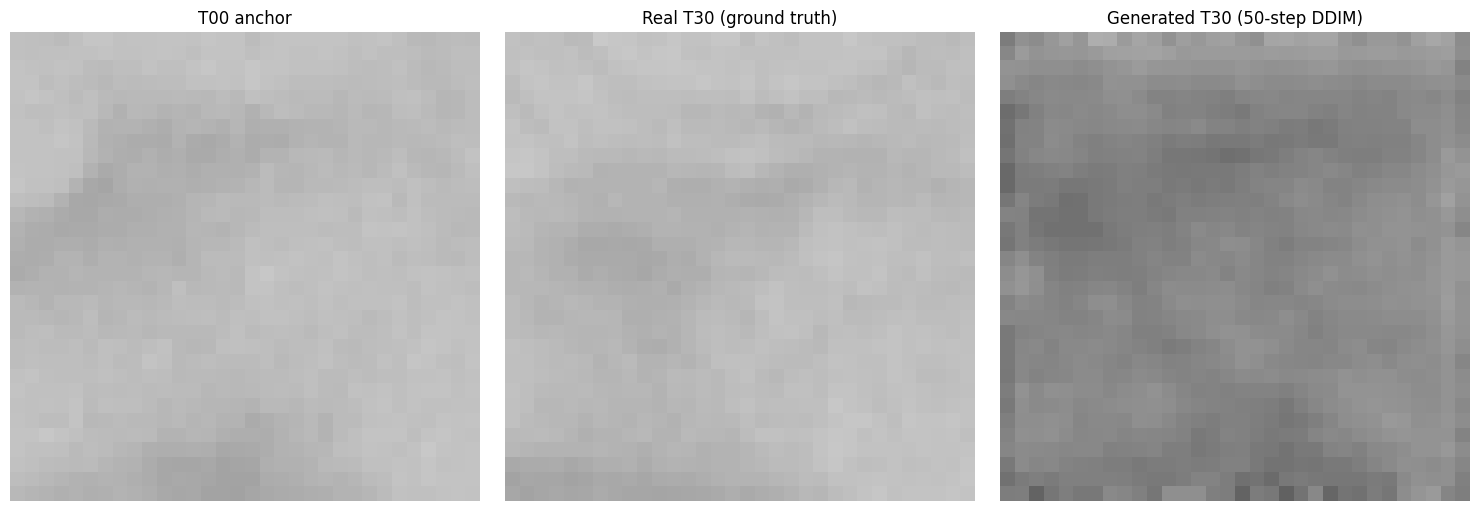

Full generation MSE vs real T30: 0.17238
Generated value range: [-1.000, 0.491]


In [10]:
import sys
sys.path.append('/content')

from ddim_sampling import DDIMSampler
from unet3d_film import UNet3DFiLM
from diffusion_training import NoiseScheduler
import numpy as np
import torch
import matplotlib.pyplot as plt
import os

device = "cuda" if torch.cuda.is_available() else "cpu"

model = UNet3DFiLM(in_channels=3, out_channels=1, base_ch=16)
model.load_state_dict(torch.load(os.path.join(BASE, "..", "checkpoints_50ep", "epoch_50.pt"), map_location=device))
model.to(device).eval()

scheduler = NoiseScheduler(num_timesteps=1000, device=device)
sampler = DDIMSampler(model, scheduler, num_steps=50, device=device)

# Reuse the center-cropped case3 patches from the diagnostic cell
# (t00_t, t50_t, t30_patch should still be in memory from before)

generated = sampler.generate(t00_t, t50_t, phase=0.3, volume_shape=(32, 32, 32))
generated_np = generated.squeeze().cpu().numpy()

mid = 16
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(t00_t.squeeze().cpu().numpy()[mid], cmap='gray', vmin=-1, vmax=1); axes[0].set_title("T00 anchor"); axes[0].axis('off')
axes[1].imshow(t30_patch[mid], cmap='gray', vmin=-1, vmax=1); axes[1].set_title("Real T30 (ground truth)"); axes[1].axis('off')
axes[2].imshow(generated_np[mid], cmap='gray', vmin=-1, vmax=1); axes[2].set_title("Generated T30 (50-step DDIM)"); axes[2].axis('off')
plt.tight_layout()
plt.show()

mse_full_gen = np.mean((generated_np - t30_patch) ** 2)
print(f"Full generation MSE vs real T30: {mse_full_gen:.5f}")
print(f"Generated value range: [{generated_np.min():.3f}, {generated_np.max():.3f}]")

In [11]:
DATASET_PATH = '/content/drive/MyDrive/Dataset 4DCT'
import os
case_dir = os.path.join(DATASET_PATH, 'Case3Pack')  # or whatever case3's actual folder is named
print(os.listdir(case_dir))

['Sampled4D', 'ExtremePhases', 'Images']


In [12]:
import os
case_dir = os.path.join(DATASET_PATH, 'Case3Pack')

print("--- ExtremePhases ---")
print(os.listdir(os.path.join(case_dir, 'ExtremePhases')))

print("\n--- Sampled4D ---")
print(os.listdir(os.path.join(case_dir, 'Sampled4D')))

--- ExtremePhases ---
['Case3_300_T00_xyz.txt', 'Case3_300_T50_xyz.txt']

--- Sampled4D ---
['case3_4D-75_T00.txt', 'case3_4D-75_T50.txt', 'case3_4D-75_T10.txt', 'case3_4D-75_T30.txt', 'case3_4D-75_T20.txt', 'case3_4D-75_T40.txt']


In [13]:
sample_file = os.path.join(case_dir, 'Sampled4D', 'case3_4D-75_T30.txt')
with open(sample_file, 'r') as f:
    lines = f.readlines()

print(f"Total lines: {len(lines)}")
print("First 5 lines:")
for line in lines[:5]:
    print(repr(line))

Total lines: 75
First 5 lines:
' 225.000000\t 121.000000\t 46.000000\t\n'
' 70.000000\t 110.000000\t 46.000000\t\n'
' 37.000000\t 132.000000\t 69.000000\t\n'
' 55.000000\t 181.000000\t 34.000000\t\n'
' 174.000000\t 179.000000\t 41.000000\t\n'


Landmarks shape: (75, 3)
First landmark (x,y,z): [226. 123.  48.]
T00 volume shape (D,H,W): (104, 256, 256)
Landmark voxel index in array: z=48, y=123, x=226


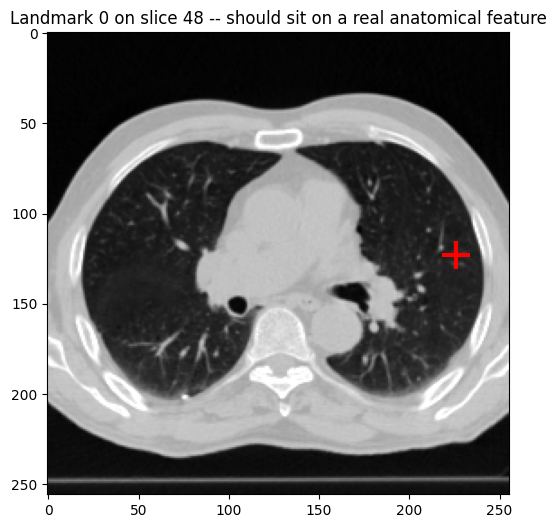

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Load landmarks
landmark_file = os.path.join(case_dir, 'Sampled4D', 'case3_4D-75_T00.txt')
landmarks = np.loadtxt(landmark_file)  # shape (75, 3) -- columns are x, y, z
print("Landmarks shape:", landmarks.shape)
print("First landmark (x,y,z):", landmarks[0])

# Load the real T00 volume (case3) -- adjust path if needed
t00_case3 = np.load(os.path.join(BASE, "case3", "T00.npy"))
print("T00 volume shape (D,H,W):", t00_case3.shape)

# Take the first landmark, convert (x,y,z) -> array indices (z,y,x)
x, y, z = landmarks[0]
z_idx, y_idx, x_idx = int(round(z)), int(round(y)), int(round(x))
print(f"Landmark voxel index in array: z={z_idx}, y={y_idx}, x={x_idx}")

# Plot the slice this landmark sits on, with a marker at its (x,y) position
fig, ax = plt.subplots(figsize=(6,6))
ax.imshow(t00_case3[z_idx], cmap='gray', vmin=-1, vmax=1)
ax.plot(x_idx, y_idx, 'r+', markersize=20, markeredgewidth=3)
ax.set_title(f"Landmark 0 on slice {z_idx} -- should sit on a real anatomical feature")
plt.show()

In [15]:
import numpy as np
import os

def load_landmarks(path):
    """Returns array of shape (N, 3), columns are (x, y, z) voxel coords."""
    return np.loadtxt(path)

def xyz_to_zyx(landmark_xyz):
    x, y, z = landmark_xyz
    return np.array([z, y, x])  # matches array indexing (D,H,W)

def extract_patch_centered(volume, center_zyx, half_size):
    z, y, x = [int(round(c)) for c in center_zyx]
    hz, hy, hx = half_size
    z0, z1 = max(0, z-hz), min(volume.shape[0], z+hz+1)
    y0, y1 = max(0, y-hy), min(volume.shape[1], y+hy+1)
    x0, x1 = max(0, x-hx), min(volume.shape[2], x+hx+1)
    return volume[z0:z1, y0:y1, x0:x1], (z0, y0, x0)

def normalized_cross_correlation(patch_a, patch_b):
    a = patch_a.flatten() - patch_a.mean()
    b = patch_b.flatten() - patch_b.mean()
    denom = (np.linalg.norm(a) * np.linalg.norm(b))
    if denom == 0:
        return -1.0
    return np.dot(a, b) / denom

def find_landmark_in_generated(generated_volume, template_patch, search_center_zyx,
                                 search_radius=(5, 10, 10), patch_half_size=(3, 5, 5)):
    """
    Slides the template patch (from T00, around the known landmark) over a local
    search window in the generated volume, and returns the voxel position with
    the highest normalized cross-correlation match.
    """
    best_score = -np.inf
    best_pos = search_center_zyx

    sz, sy, sx = search_center_zyx
    rz, ry, rx = search_radius

    for dz in range(-rz, rz+1):
        for dy in range(-ry, ry+1, 2):   # step by 2 to keep this fast
            for dx in range(-rx, rx+1, 2):
                center = (sz+dz, sy+dy, sx+dx)
                candidate_patch, _ = extract_patch_centered(generated_volume, center, patch_half_size)
                if candidate_patch.shape != template_patch.shape:
                    continue
                score = normalized_cross_correlation(template_patch, candidate_patch)
                if score > best_score:
                    best_score = score
                    best_pos = center

    return best_pos, best_score


def compute_tre_for_case(case_id, phase, t00_volume, generated_volume,
                           landmark_dir, voxel_spacing_mm):
    """
    voxel_spacing_mm: (z_spacing, y_spacing, x_spacing) in mm -- must match this case's
    actual DIR-Lab spacing, NOT assumed.
    """
    t00_lm_path = os.path.join(landmark_dir, f"case{case_id}_4D-75_T00.txt")
    target_lm_path = os.path.join(landmark_dir, f"case{case_id}_4D-75_{phase}.txt")

    t00_landmarks = load_landmarks(t00_lm_path)
    target_landmarks_gt = load_landmarks(target_lm_path)  # ground truth for scoring

    tre_values = []
    for i in range(len(t00_landmarks)):
        t00_zyx = xyz_to_zyx(t00_landmarks[i])
        gt_zyx = xyz_to_zyx(target_landmarks_gt[i])

        template_patch, _ = extract_patch_centered(t00_volume, t00_zyx, patch_half_size=(3,5,5))

        detected_zyx, score = find_landmark_in_generated(
            generated_volume, template_patch, search_center_zyx=t00_zyx
        )

        # Distance in voxels -> mm using per-axis spacing
        diff_voxels = np.array(detected_zyx) - np.array(gt_zyx)
        diff_mm = diff_voxels * np.array(voxel_spacing_mm)
        tre_mm = np.linalg.norm(diff_mm)
        tre_values.append(tre_mm)

    return np.array(tre_values)